<a href="https://colab.research.google.com/github/Dnntello/Prodigy_ML_03/blob/main/cats_and_dogs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import zipfile

# zip_path = "drive/MyDrive/cats_and_dogs/catsanddogs.zip"
# extract_path = "drive/MyDrive/cats_and_dogs/data"

# with zipfile.ZipFile(zip_path, "r") as zip_ref:
#   zip_ref.extractall(extract_path)


In [2]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pandas as pd

In [3]:
labels_csv = pd.read_csv("drive/MyDrive/cats_and_dogs/data/train/train_label.csv")
labels_csv.head()

,file name,label
0,cat0.jpg,0
1,cat1.jpg,0
2,cat2.jpg,0
3,cat3.jpg,0
4,cat4.jpg,0


In [4]:
labels_csv["label"].value_counts()

,count
label,
1,10471
0,7917


In [5]:
labels_csv[labels_csv["label"] == 1].index[0]

np.int64(7917)

The dog images doesnt start appearing until the 7917th index. Since I am not using all the data to train my model, i have to keep that in consideration

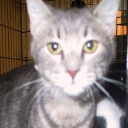

In [6]:
from IPython.display import Image
Image('drive/MyDrive/cats_and_dogs/data/train/cat4.jpg')

### Let's get our data ready

In [7]:
# create pathnames for image names
filenames = ["drive/MyDrive/cats_and_dogs/data/train/" + fname for fname in labels_csv["file name"]]

#check first 10
filenames[:10]

['drive/MyDrive/cats_and_dogs/data/train/cat0.jpg',
 'drive/MyDrive/cats_and_dogs/data/train/cat1.jpg',
 'drive/MyDrive/cats_and_dogs/data/train/cat2.jpg',
 'drive/MyDrive/cats_and_dogs/data/train/cat3.jpg',
 'drive/MyDrive/cats_and_dogs/data/train/cat4.jpg',
 'drive/MyDrive/cats_and_dogs/data/train/cat5.jpg',
 'drive/MyDrive/cats_and_dogs/data/train/cat6.jpg',
 'drive/MyDrive/cats_and_dogs/data/train/cat7.jpg',
 'drive/MyDrive/cats_and_dogs/data/train/cat8.jpg',
 'drive/MyDrive/cats_and_dogs/data/train/cat9.jpg']

In [8]:
#check whether filenames match the actual number of images
if len(os.listdir("drive/MyDrive/cats_and_dogs/data/train/")) - 1 == len(filenames):
  print("Everything is fine bruda!")
else:
  print("panic broo")


Everything is fine bruda!


In [9]:
len(filenames)

18388

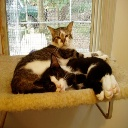

In [10]:
Image(filenames[2000])

In [11]:
labels_csv["label"][2000]

np.int64(0)

Since we've gotten our training images filepaths into a list, lets work on our labels

In [12]:
labels = labels_csv["label"].to_numpy()
labels

array([0, 0, 0, ..., 1, 1, 1])

In [13]:
len(labels)

18388

Let's create a function to process our images

In [14]:
#L
%%time
from skimage.feature import hog

def preprocessing(filenames):
  image = []
  for fname in filenames:
    #read image
    img = cv2.imread(fname)

    #resize image
    img = cv2.resize(img, (100, 100))  #as smaller images train faster

    #convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(4,4),
        cells_per_block=(2,2),
        feature_vector=True,
        transform_sqrt=True
    )

    image.append(features)

  return image

image = preprocessing(filenames[6400:9400])
len(image)

CPU times: user 40.9 s, sys: 2.08 s, total: 43 s
Wall time: 8min 51s


3000

#### lets create X and y

In [15]:
# we are going to experiment with 2000 images
X = image
y = labels[6400:9400]

In [16]:
X = np.array(X)
X.shape

(3000, 20736)

In [17]:
#TRAIN_TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)
y_train.shape, y_test.shape

((2400,), (600,))

Lets scale features

In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

### TRAIN SVC MODEL

In [19]:
svm = SVC(
    kernel='linear'
)

svm.fit(X_train, y_train)

SVC(kernel='linear')

In [20]:
svm.score(X_train, y_train)

1.0

In [21]:
svm.score(X_test, y_test)

0.6666666666666666

# 66.7% is really a terrible score

Lets create an evaluation function

Classification report:               precision    recall  f1-score   support

           0       0.67      0.67      0.67       303
           1       0.66      0.66      0.66       297

    accuracy                           0.67       600
   macro avg       0.67      0.67      0.67       600
weighted avg       0.67      0.67      0.67       600



Accuracy: 66.66666666666666


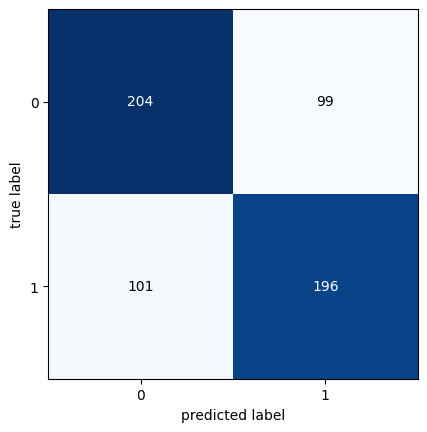

In [22]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from mlxtend.plotting import plot_confusion_matrix

def metrics(X_test, y_test, model):
  y_preds = model.predict(X_test)

  print("Classification report:", classification_report(y_test, y_preds))
  print("\n")
  print("Accuracy:", (accuracy_score(y_test, y_preds)*100))

  plot_confusion_matrix(confusion_matrix(y_test, y_preds))
  plt.show()

metrics(X_test, y_test, svm)




###Retraining the model
* I'll use 'kernel=rbf' this time around

In [23]:
#train model ussing kernel=rbf
svm_rbf = SVC(kernel = 'rbf')

svm_rbf = svm_rbf.fit(X_train, y_train)

In [24]:
svm_rbf.score(X_train, y_train), svm_rbf.score(X_test, y_test)

(0.9875, 0.72)

Classification report:               precision    recall  f1-score   support

           0       0.72      0.72      0.72       303
           1       0.72      0.72      0.72       297

    accuracy                           0.72       600
   macro avg       0.72      0.72      0.72       600
weighted avg       0.72      0.72      0.72       600



Accuracy: 72.0


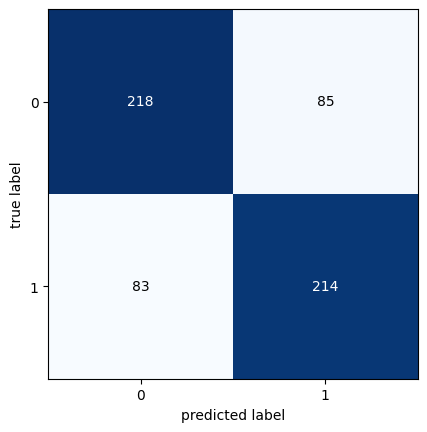

In [25]:
metrics(X_test, y_test, svm_rbf)

### Hyperparameter tuning

In [30]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

random = RandomizedSearchCV(SVC(),
                            param_distributions = params,
                            n_iter = 12,
                            verbose = 1,
                            random_state  = 42)
random.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=12. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 9 candidates, totalling 45 fits


RandomizedSearchCV(estimator=SVC(), n_iter=12,
                   param_distributions={'C': [0.1, 1, 10],
                                        'gamma': ['scale', 0.01, 0.001],
                                        'kernel': ['rbf']},
                   random_state=42, verbose=1)

In [31]:
#best model
random.best_estimator_
random.score(X_test, y_test)

0.72

In [32]:
random.best_params_

{'kernel': 'rbf', 'gamma': 'scale', 'C': 1}

Classification report:               precision    recall  f1-score   support

           0       0.72      0.72      0.72       303
           1       0.72      0.72      0.72       297

    accuracy                           0.72       600
   macro avg       0.72      0.72      0.72       600
weighted avg       0.72      0.72      0.72       600



Accuracy: 72.0


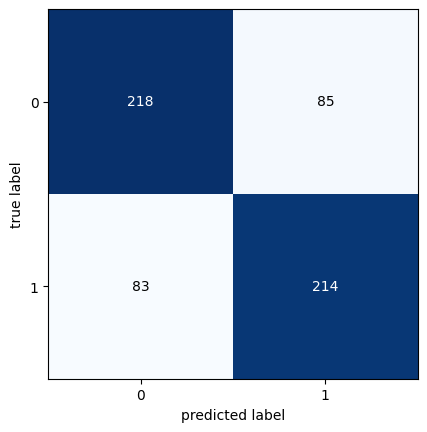

In [33]:
metrics(X_test, y_test, random)

### Imagine getting 72% accuracy after waiting for my RandomSearchCV model to train🙄

**As we can see ladies and gentlemen, this was the best i was able to get out of this problem using SVC based on time constraints**
* CNNs are best for image modelling
* HOG (Histogram of oriented gradients) was used to focus edge, shapes and structures of our images which is important for SVC
* Even after hyperparameter tuning using RandomizedSearchCV, the model didnt yield much result